# Who is the best footballer of the last 25 years?

Most arguments about the greatest player are not really disagreements about
facts. They are disagreements about **what the question means**, conducted as
though they were about facts. One person means peak. Another means longevity. A
third means trophies. Nobody says which, so nobody can be wrong, and nobody ever
moves.

I wanted to take a different route. Instead of arguing about the answer, I wrote
down **what greatness requires**, twelve things a player must have, and then
asked who has all of them.

By this definition, a player who fails any single requirement is not the best.
And I publish which requirement they failed, so you can argue with the
definition instead of just taking my word for it.

In [1]:
import warnings

import matplotlib
import pandas as pd

from gambeta import needs, tifo

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (10, 5.5)

SAMPLE = "../data/sample"
ranking = pd.read_parquet(f"{SAMPLE}/ranking.parquet")
seasons = pd.read_parquet(f"{SAMPLE}/player_season_scored.parquet")
offsets = pd.read_parquet(f"{SAMPLE}/league_offsets.parquet")
keepers = pd.read_parquet(f"{SAMPLE}/keeper_ranking.parquet")

first = tifo.season_label(seasons["season"].min())
last = tifo.season_label(seasons["season"].max())

print(f"{len(ranking):,} players ranked")
print(f"{len(seasons):,} player-seasons")
print(f"leagues: {', '.join(sorted(seasons['league'].unique()))}")
print(f"seasons: {first} to {last}")

5,508 players ranked
39,877 player-seasons
leagues: ENG-Premier League, ESP-La Liga, FRA-Ligue 1, GER-Bundesliga, ITA-Serie A
seasons: 2000-01 to 2024-25


## The twelve requirements

Each one is measured across every season and every league, then pooled per
player and weighted by minutes. All of them are oriented so that **higher is
better**, including discipline, which gets negated at source. That way a clean
player scores above a dirty one and no code downstream has to remember which
direction any particular metric runs in.

In [2]:
pd.DataFrame(
    [
        {"#": i + 1, "requirement": r.label, "key": r.key, "grain": r.kind}
        for i, r in enumerate(needs.OUTFIELD)
    ]
).set_index("#")

,requirement,key,grain
#,,,
1,Scores goals,scoring,season
2,Creates goals,creation,season
3,Finishes clinically,finishing,season
4,Generates threat,threat,season
5,Carries his team,team_share,season
6,Is available,availability,season
7,Sees matches out,reliability,season
8,Sustains it,longevity,career
9,Has no bad seasons,consistency,career


### One competition, one yardstick

Requirements 11 and 12 are scored in competitions the whole Big 5 shares, and
that raises a question the other season-level requirements never face: **who
is the comparison population?** For the eight domestic requirements the answer
is easy, the league-season the player actually played in. For the Champions
League and the international tournaments there were two candidate rules, and
the pipeline has used both, so I show them side by side rather than asking you
to trust the one that shipped. The old rule z-scored `continental` within
`(league, season)`, the same grain as everything else, and then added the
domestic league-strength offset on top. The shipped rule z-scores it within
`(season)`, pooled across all five leagues, with no offset. The table below
computes the career continental z for Messi, Ronaldo and Mbappé under both
rules, live from the season table.

In [3]:
from gambeta import level

trio = ["Lionel Messi", "Cristiano Ronaldo", "Kylian Mbappé"]


def career_continental(by, with_offset):
    """Career continental z under a chosen normalisation grain.

    Replicates the pipeline's pooling for one column: z-score the raw
    per-season values at the given grain, optionally add the domestic
    league-strength offset (the old rule did, the shipped rule does not),
    pool each career weighted by minutes, then standardise across every
    career of three seasons or more.
    """
    z = level.zscore(seasons, ["continental"], by=by)
    z["v"] = z["continental_z"]
    if with_offset:
        z = z.merge(offsets[["league", "season", "offset"]], on=["league", "season"], how="left")
        z["v"] = z["v"] + z["offset"].fillna(0.0)
    z["_w"] = z["minutes"].where(z["minutes"] > 0, 1e-9)
    z["_wv"] = z["v"] * z["_w"]
    g = z.groupby(["player_id", "player"], as_index=False).agg(
        wv=("_wv", "sum"), w=("_w", "sum"), n=("season", "size")
    )
    g = g[g["n"] >= 3]
    pooled = g["wv"] / g["w"]
    g["career_z"] = (pooled - pooled.mean()) / pooled.std(ddof=0)
    return g.set_index("player")["career_z"]


old_way = career_continental(("league", "season"), with_offset=True)
new_way = career_continental(("season",), with_offset=False)
pd.DataFrame(
    {
        "within (league, season), the old way": old_way[trio].round(2),
        "within (season) pooled, shipped": new_way[trio].round(2),
    }
)

,"within (league, season), the old way","within (season) pooled, shipped"
player,,
Lionel Messi,10.74,12.86
Cristiano Ronaldo,9.64,12.07
Kylian Mbappé,14.35,11.22


The case **for** the within-league grain is real, which is why the pipeline
shipped with it for a while: one uniform normalisation rule for all ten
season-level columns, and a defensible reading of its own, dominance in your
own domestic context. The case **against** is the one I find decisive: a
z-score's yardstick population has to match the construct's population.
"Delivers in Europe" is a claim about everyone who played that European
season, not about a player relative to his domestic league-mates, so under
the within-league grain a player's European score depended on how many of his
league-mates were also in Europe. That is a club and league artifact, not a
football fact, and the table above demonstrates it: a dominant club in a
league that sends little else deep into Europe gets its European output
measured against a thin domestic comparison set. Under the old rule Mbappé's
career continental z towers over Ronaldo's, roughly 14.3 against 9.6, an
ordering no reading of the two European careers supports. Pool the yardstick
and the same seasons give Ronaldo about 12.1 to Mbappé's 11.2, with Messi
highest under both rules.

My ruling is the pooled grain, and the consequence is stated plainly: this
change is what moves Ronaldo back above Mbappé in the table below. The podium
change is the artifact leaving, not football changing. The domestic
league-strength offset also no longer touches these two columns, because a
Champions League goal is the same event whichever domestic league the scorer
plays in.

What the fix does not solve, so nobody mistakes it for more than it is: most
careers never touch Europe at all, so the zero mass still skews this column
and the trio above still sit ten-plus standard deviations up, far beyond what
a normal scale can honestly convey; and club selection remains a confound,
because Totti at Roma and Messi at Barcelona did not face the same
opportunity. Both caveats are unchanged from the requirement's own
documentation, and "What would change my mind" below keeps them on the
record.

## Gate first, then rank

I read "must have" literally. A player has to clear the 40th percentile on **all
twelve** requirements to qualify at all. Only then do the qualifiers get ranked.

A weighted average on its own would let a player be genuinely poor at something
my own list calls mandatory and still win on volume elsewhere. The gate is what
stops that from happening.

In [4]:
qualified = ranking[ranking["qualified"]]
print(
    f"{len(qualified)} of {len(ranking):,} players clear every requirement "
    f"({100 * len(qualified) / len(ranking):.1f}%)"
)

qualified.head(15)[["player", "score", "seasons", "leagues"]].round(2)

265 of 5,508 players clear every requirement (4.8%)


,player,score,seasons,leagues
0,Lionel Messi,4.84,18,"ESP-La Liga, FRA-Ligue 1"
1,Cristiano Ronaldo,4.13,19,"ENG-Premier League, ESP-La Liga, ITA-Serie A"
2,Kylian Mbappé,3.94,9,"ESP-La Liga, FRA-Ligue 1"
3,Thierry Henry,3.69,10,"ENG-Premier League, ESP-La Liga"
4,Robert Lewandowski,3.28,15,"ESP-La Liga, GER-Bundesliga"
5,Harry Kane,3.10,11,"ENG-Premier League, GER-Bundesliga"
6,Karim Benzema,3.08,17,"ESP-La Liga, FRA-Ligue 1"
7,Erling Haaland,3.08,6,"ENG-Premier League, GER-Bundesliga"
8,Luis Suárez,3.00,12,"ENG-Premier League, ESP-La Liga"
9,Ruud van Nistelrooy,3.00,9,"ENG-Premier League, ESP-La Liga, GER-Bundesliga"


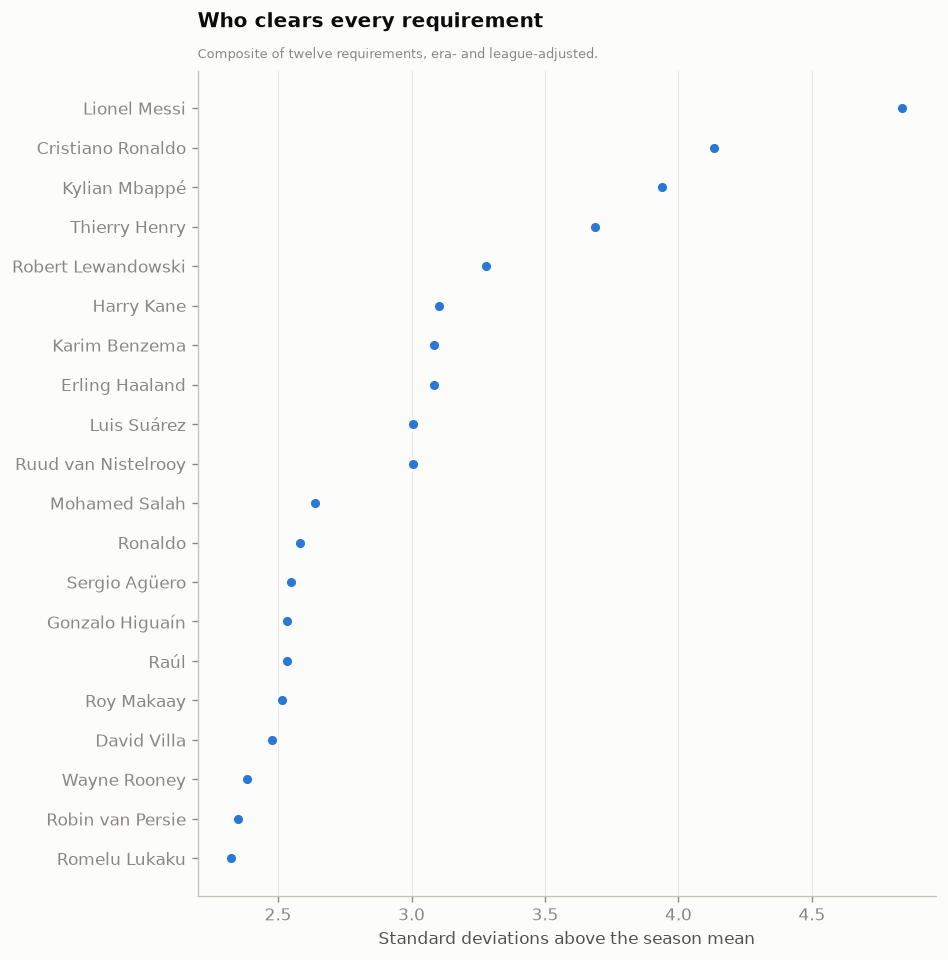

In [5]:
fig = tifo.ranked_dots(
    qualified.assign(lo=qualified["score"], hi=qualified["score"]),
    top=20,
    title="Who clears every requirement",
    subtitle="Composite of twelve requirements, era- and league-adjusted.",
)

One absence from the top ten deserves naming beside the table rather than a
line in a changelog. Salah sits 11th, and what holds him out is the
`tournament` requirement's scope: Egypt's tournament is the Africa Cup of
Nations, which is not in it, so his international column carries only a World
Cup. Score the same qualifiers without the tournament requirement and he is
9th. I verified that against the current outputs before asserting it here.
His exclusion from the top ten is my scope ruling, not his football.

## A career is not league-bound

Look at the `leagues` column. Ronaldo's career is England, Spain and Italy:
nineteen seasons pooled into one player, not three separate league careers.

This is the single most important structural decision in the whole project.
Ranking "the best player in a league" answers a different and much less
interesting question, and it makes anybody who transferred impossible to
evaluate.

In [6]:
multi = qualified[qualified["leagues"].str.contains(",")]
print(f"{len(multi)} of the {len(qualified)} qualifiers played in more than one league")

119 of the 265 qualifiers played in more than one league


## Who fails, and on what

This is the part most rankings quietly hide. A great player missing the cut is
more informative than one making it, because it shows you exactly where the
definition bites.

In [7]:
near = ranking[~ranking["qualified"]].copy()
near["missed"] = near["failed"].fillna("").apply(lambda s: len(s.split(", ")) if s else 0)

one = near[near["missed"] == 1].nlargest(12, "score")
one[["player", "score", "seasons", "failed"]].round(2)

,player,score,seasons,failed
265,Neymar,3.22,10,discipline
267,Rivaldo,2.69,3,longevity
268,Zlatan Ibrahimović,2.59,16,discipline
269,Lautaro Martínez,2.39,7,discipline
270,Didier Drogba,2.37,10,discipline
272,Julián Álvarez,2.26,3,longevity
273,Christian Vieri,2.24,6,availability
276,Olivier Giroud,2.04,12,discipline
277,Giovane Élber,2.04,4,longevity
279,Fernando Torres,1.98,16,discipline


Two views of the same failures, and they earn their places differently. The
per-requirement table is **flat by construction**: the gate is a percentile,
so every requirement eliminates the same share of the population, and the
table can only confirm that the floors landed where they were told to. It
proves calibration, nothing more. The statistic that actually describes the
non-qualifiers is the second one: **how many requirements each of them
missed**. A few hundred players fall one requirement short of qualifying,
the bulk miss on several at once, and a small handful at the bottom fail all
twelve.

In [8]:
flat = pd.read_csv(f"{SAMPLE}/failures.csv")
print("eliminated per requirement, flat by construction at a percentile gate:")
print(flat.to_string(index=False))

near["missed"].value_counts().sort_index().rename_axis("requirements missed").to_frame("players")

eliminated per requirement, flat by construction at a percentile gate:
 requirement                    label  eliminated
     scoring             Scores goals        2203
    creation            Creates goals        2203
   finishing      Finishes clinically        2203
      threat         Generates threat        2203
  team_share         Carries his team        2203
availability             Is available        2203
 reliability         Sees matches out        2203
 consistency       Has no bad seasons        2203
  discipline   Does not cost his team        2203
 continental       Delivers in Europe        2203
  tournament Shows up for his country        2203
   longevity              Sustains it        2152


,players
requirements missed,
1,481
2,648
3,683
4,640
5,548
6,533
7,582
8,522
9,346


## Goalkeepers, judged on their own job

Keepers score zero on goals and assists, so under an attacking rating they come
out near the bottom, which tells you nothing. They get a parallel list of eight
requirements built from save percentage, clean sheets and goals conceded.

I am **not** claiming they are comparable with outfielders. Two leaderboards, no
combined number, because the data cannot support one.

In [9]:
kq = keepers[keepers["qualified"]]
print(f"{len(kq)} of {len(keepers)} keepers qualify\n")
kq.head(10)[["player", "score", "seasons", "leagues"]].round(2)

72 of 395 keepers qualify



,player,score,seasons,leagues
0,Santiago Cañizares,2.00,8,ESP-La Liga
1,Manuel Neuer,1.85,18,GER-Bundesliga
2,Víctor Valdés,1.68,13,"ENG-Premier League, ESP-La Liga"
3,Ederson Moraes,1.62,8,ENG-Premier League
4,Marc-André ter Stegen,1.62,11,"ESP-La Liga, GER-Bundesliga"
5,Roman Weidenfeller,1.61,13,GER-Bundesliga
6,José Molina,1.49,7,ESP-La Liga
7,Petr Čech,1.46,15,"ENG-Premier League, FRA-Ligue 1"
8,Sven Ulreich,1.46,8,GER-Bundesliga
9,Jan Oblak,1.43,11,ESP-La Liga


## What would change my mind

A conclusion is worth what its author would abandon it for. So here is mine:

1. **Defensive contribution.** FBref records no per-player defensive action
   before 2017-18, so a centre-back is invisible to requirements 1 through 6.
   This is an attacking-contribution rating and I name it as such. Real
   defensive data would change the list completely.
2. **The gate height.** The 40th percentile is a judgement call. Raise it to 50
   and players sitting just inside get disqualified.
3. **The weights.** Every requirement counts equally right now. If you think
   scoring matters more than availability, you can say so numerically and watch
   the ranking move.
4. **Missing football, narrower than it used to be.** `continental` and
   `tournament` now bring the Champions League and the major international
   tournaments into the count, so those are no longer invisible. What is still
   missing is everything outside the Big 5 and outside those specific
   competitions: no Europa League, no other confederations' cups, and careers
   at Sporting, Al-Nassr or Inter Miami stay invisible here.

The productive question is not "is this wrong". It is **"which of those four
would you change, and to what"**, which is an argument that can actually get
somewhere.